In [1]:
import torch
print(torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.10.0+cu128
GPU: Tesla T4


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
class PrunableLinear(nn.Module):
    """
    Custom linear layer with a learnable gate per weight.
    gate = sigmoid(gate_score) in (0,1)
    pruned_weight = weight * gate
    If gate → 0, that weight is effectively removed (pruned).
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)

    def forward(self, x):
        gates          = torch.sigmoid(self.gate_scores)  
        pruned_weights = self.weight * gates              
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        with torch.no_grad():
            return torch.sigmoid(self.gate_scores).cpu()

In [5]:
class SelfPruningNet(nn.Module):
    """
    Feed-forward net for CIFAR-10 (3072 input dims).
    All linear layers are PrunableLinear.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            PrunableLinear(3072, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),

            PrunableLinear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),

            PrunableLinear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),

            PrunableLinear(256, 10),
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))   

    def prunable_layers(self):
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                yield m

In [6]:
def sparsity_loss(model):

    total = torch.tensor(0.0, device=DEVICE)
    for layer in model.prunable_layers():
        total += torch.sigmoid(layer.gate_scores).sum()
    return total

In [20]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/readme.html


In [21]:
import pickle

def get_dataloaders(batch_size=128):
    base = '/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py'

    def load_batch(filepath):
        with open(filepath, 'rb') as f:
            d = pickle.load(f, encoding='bytes')
        imgs = d[b'data'].reshape(-1, 3, 32, 32).astype('float32') / 255.0
        lbls = d[b'labels']
        return imgs, lbls

    train_imgs, train_lbls = [], []
    for i in range(1, 6):
        imgs, lbls = load_batch(f'{base}/data_batch_{i}')
        train_imgs.append(imgs)
        train_lbls.extend(lbls)
    train_imgs = np.concatenate(train_imgs)

    test_imgs, test_lbls = load_batch(f'{base}/test_batch')

    mean = np.array([0.4914, 0.4822, 0.4465], dtype='float32').reshape(1,3,1,1)
    std  = np.array([0.2470, 0.2435, 0.2616], dtype='float32').reshape(1,3,1,1)
    train_imgs = (train_imgs - mean) / std
    test_imgs  = (test_imgs  - mean) / std

    X_train = torch.tensor(train_imgs)
    y_train = torch.tensor(train_lbls, dtype=torch.long)
    X_test  = torch.tensor(test_imgs)
    y_test  = torch.tensor(test_lbls,  dtype=torch.long)

    class AugDataset(torch.utils.data.Dataset):
        def __init__(self, X, y, augment=False):
            self.X, self.y, self.augment = X, y, augment
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            x = self.X[idx]
            if self.augment:
                if torch.rand(1) > 0.5:
                    x = torch.flip(x, dims=[2])
                x = F.pad(x, [4,4,4,4], mode='reflect')
                i = torch.randint(0, 8, (1,)).item()
                j = torch.randint(0, 8, (1,)).item()
                x = x[:, i:i+32, j:j+32]
            return x, self.y[idx]

    train_loader = DataLoader(AugDataset(X_train, y_train, augment=True),
                              batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(AugDataset(X_test, y_test, augment=False),
                              batch_size=256, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, test_loader

tr, te = get_dataloaders()
x, y = next(iter(tr))
print(f" Data loaded! Batch shape: {x.shape}")

 Data loaded! Batch shape: torch.Size([128, 3, 32, 32])


In [32]:
def train(lam, epochs=50):
    print(f"\n{'='*50}\n  Training with λ = {lam}\n{'='*50}")

    train_loader, test_loader = get_dataloaders()
    model     = SelfPruningNet().to(DEVICE)

    weight_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]
    gate_params   = [p for n, p in model.named_parameters() if 'gate_scores' in n]

    optimizer = torch.optim.Adam([
        {'params': weight_params, 'lr': 1e-3, 'weight_decay': 1e-4},
        {'params': gate_params,   'lr': 1e-3}  
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        cls_total = spar_total = 0.0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            cls_l  = criterion(model(images), labels)
            spar_l = sparsity_loss(model)
            loss   = cls_l + lam * spar_l

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                for layer in model.prunable_layers():
                    layer.gate_scores.clamp_(-5.0, 5.0)

            cls_total  += cls_l.item()
            spar_total += spar_l.item()

        scheduler.step()

        if epoch % 10 == 0 or epoch == 1:
            all_gates = torch.cat([
                l.get_gates().flatten() for l in model.prunable_layers()
            ]).numpy()
            live_sparsity = 100.0 * (all_gates < 1e-2).sum() / len(all_gates)
            n = len(train_loader)
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"cls={cls_total/n:.3f} | "
                  f"spar={spar_total/n:.1f} | "
                  f"sparsity={live_sparsity:.1f}%")

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            correct += (model(images).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    accuracy = 100.0 * correct / total

    all_gates = torch.cat([
        l.get_gates().flatten() for l in model.prunable_layers()
    ]).numpy()
    sparsity = 100.0 * (all_gates < 1e-2).sum() / len(all_gates)

    print(f"\n  λ={lam} → Accuracy: {accuracy:.2f}% | Sparsity: {sparsity:.1f}%")
    return {"lambda": lam, "accuracy": accuracy, "sparsity": sparsity, "gates": all_gates}

In [39]:
LAMBDAS = [1e-6, 1e-5, 1e-4]
results = [train(lam=lam, epochs=50) for lam in LAMBDAS]


  Training with λ = 1e-06
  Epoch   1/50 | cls=1.713 | spar=1850031.5 | sparsity=0.0%
  Epoch  10/50 | cls=1.286 | spar=1058449.2 | sparsity=0.0%
  Epoch  20/50 | cls=1.126 | spar=705842.4 | sparsity=0.0%
  Epoch  30/50 | cls=0.979 | spar=567949.9 | sparsity=5.8%
  Epoch  40/50 | cls=0.847 | spar=523287.7 | sparsity=18.2%
  Epoch  50/50 | cls=0.798 | spar=516054.5 | sparsity=20.3%

  λ=1e-06 → Accuracy: 66.00% | Sparsity: 20.3%

  Training with λ = 1e-05
  Epoch   1/50 | cls=1.717 | spar=1751097.9 | sparsity=0.0%
  Epoch  10/50 | cls=1.257 | spar=405976.6 | sparsity=0.0%
  Epoch  20/50 | cls=1.095 | spar=185086.3 | sparsity=0.0%
  Epoch  30/50 | cls=0.970 | spar=134841.4 | sparsity=55.3%
  Epoch  40/50 | cls=0.876 | spar=124038.8 | sparsity=61.5%
  Epoch  50/50 | cls=0.839 | spar=122289.8 | sparsity=62.4%

  λ=1e-05 → Accuracy: 66.57% | Sparsity: 62.4%

  Training with λ = 0.0001
  Epoch   1/50 | cls=1.715 | spar=1719988.4 | sparsity=0.0%
  Epoch  10/50 | cls=1.281 | spar=243674.9 | s

In [40]:
print(f"\n{'='*52}")
print(f"  {'Lambda':<12} {'Test Accuracy (%)':^20} {'Sparsity (%)':^12}")
print(f"  {'-'*48}")
for r in results:
    print(f"  {r['lambda']:<12.0e} {r['accuracy']:^20.2f} {r['sparsity']:^12.1f}")
print(f"{'='*52}")


  Lambda        Test Accuracy (%)   Sparsity (%)
  ------------------------------------------------
  1e-06               66.00             20.3    
  1e-05               66.57             62.4    
  1e-04               65.20             87.7    


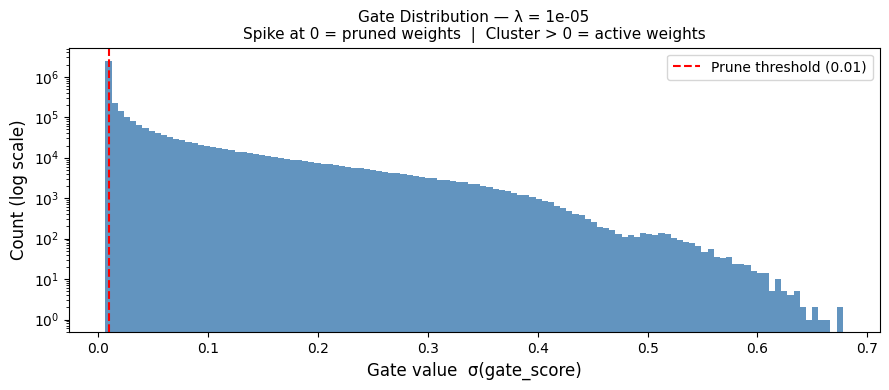

 Saved: gate_distribution.png


In [41]:
best  = max(results, key=lambda r: r['accuracy'])
gates = best['gates']

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(gates, bins=120, color='steelblue', alpha=0.85, edgecolor='none')
ax.axvline(0.01, color='red', linestyle='--', linewidth=1.5,
           label='Prune threshold (0.01)')
ax.set_yscale('log')
ax.set_xlabel('Gate value  σ(gate_score)', fontsize=12)
ax.set_ylabel('Count (log scale)', fontsize=12)
ax.set_title(
    f"Gate Distribution — λ = {best['lambda']}\n"
    f"Spike at 0 = pruned weights  |  Cluster > 0 = active weights",
    fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('gate_distribution.png', dpi=150)
plt.show()
print(" Saved: gate_distribution.png")